<a href="https://colab.research.google.com/github/gitnicolas343/intro_neurociencias_Computacionesles_phyton/blob/main/Lab8_MEA_Conectividad_Funcional_VClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8: Análisis de datos de Múltiples Spike-Trains

### Introducción al análisis de datos  

Los datos que utilizaremos provienen de un estudio realizado por Snyder et al. (2015) con el objetivo de analizar la actividad neuronal a diferentes escalas. Para ello, se registró simultáneamente la actividad neuronal de monos macacos rhesus utilizando una matriz de 96 electrodos implantada en la corteza visual (área V4).

Nuestro interés principal es analizar la **correlación del conteo de picos (spike count correlation)**, una medida de la conectividad funcional entre neuronas. La conectividad funcional se refiere a la correlación en la actividad de diferentes neuronas o regiones cerebrales, lo que sugiere que pueden estar trabajando en conjunto. Un punto clave es que esta conectividad puede variar según las condiciones experimentales, lo que permite inferir relaciones funcionales entre las neuronas.  

### Diseño experimental  

Los registros provienen de una **matriz de microelectrodos Utah**, que consiste en una cuadrícula de 10 × 10 electrodos implantada en la corteza visual.

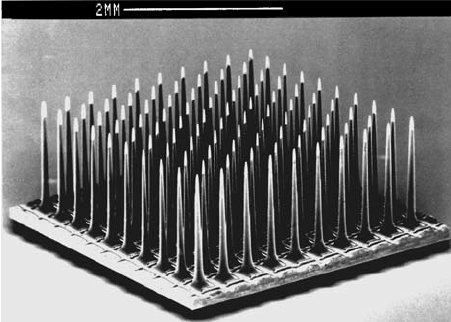

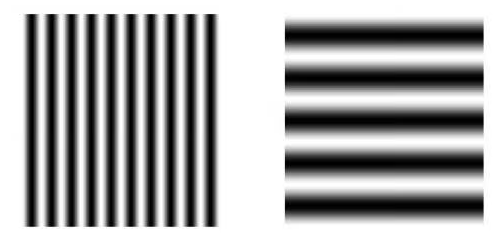

Cada electrodo capta señales de pequeñas poblaciones neuronales cercanas. Para aislar la actividad de neuronas individuales, los datos han sido previamente procesados mediante un método llamado **spike sorting**, que separa los picos de potencial eléctrico detectados por los electrodos y los asigna a neuronas específicas. En este ejercicio ya se ha realizado el spike-sorting.

Los datos se obtuvieron durante un experimento en el que los monos observaban **rejillas sinusoidales en movimiento** (imágenes con patrones de ondas sinusoidales), un estímulo visual comúnmente utilizado en neurociencia para activar neuronas de la corteza visual. Se realizaron **2300 ensayos**, cada uno de **2650 ms**, en los que se presentaron rejillas con dos orientaciones: **0° (barras horizontales)** y **90° (barras verticales)**.  


De los **2650 ms** de cada experimento **150 ms** corresponden a tiempo antes de presentación del estimulo en el que el mono es entrenado a ver una pantalla fijamente con un solo punto, **2000 ms** de presentación de estímulo y **500 ms** de terminación del experimento.

### Preguntas de investigación  

El análisis de datos abordará dos preguntas principales:  

1. **¿Las neuronas registradas responden al estímulo visual y muestran sensibilidad a la orientación de la rejilla?**  
2. **¿La estimulación con la rejilla sinusoidal incrementa la conectividad funcional entre las neuronas?**  
   - En caso afirmativo, ¿este aumento depende de la orientación del estímulo?  

### Hipótesis  

Dado que las neuronas de la corteza visual están sintonizadas a orientaciones específicas, esperamos que algunas neuronas respondan más a las rejillas en 0° y otras a las de 90°. Asimismo, se espera que la conectividad funcional aumente durante la estimulación visual, ya que las neuronas con la misma preferencia de orientación activarán en conjunto, mostrando correlaciones más altas en sus patrones de disparo.  

Este análisis nos permitirá explorar cómo las neuronas de la corteza visual procesan información y se conectan funcionalmente en respuesta a estímulos específicos.

## Datos

Los datos han sido recolectados en un archivo csv, haga uso de la librería pandas para importar los datos. En los datos encontrará 4 columnas.

 1. Channel: El canal dentro de los 96 electrodos donde fue registrado el spike. Para efectos de este ejercicio podemos suponer que cada electrodo corresponde a una neurona particular
 2. Time: El tiempo en el que se registró un spike en el canal (neurona). Tiempos negativos corresponden a tiempos antes de presentación del estímulo que se considera en t = 0.
 3. Orientation: La condición experimental en la que se registró el evento
     * 0: Barras Horizontales, 90: Barras Verticales
 4. Trial: El número del ensayo en el que se registró el evento

## Ejercicio 1

Realice un análisis exploratorio y responda las siguientes preguntas

1. Cuántas neuronas (canales) diferentes tenemos registrados en este experimento?
2. Seleccione el canal 63 y el 80 y para cada uno de los dos canales haga 2 raster plots en los que muestre los spikes generados durante los 1500 ensayos para las franjas verticales y los 1500 ensayos horizontales. Describa las diferencias cualitativas en ambos casos.
    * **Nota:** Es posible que el rasterplot sea muy denso si desea mostrar los 1500 ensayos, si esto sucede restrinja el raster plot solo para visualziar los primeros 500 ensayos

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# tiempos importantes
trial_start_time = -0.150
grating_on_time  = 0.0
grating_off_time = 2.0
trial_end_time   = 2.5

In [ ]:
#importacion de datos
multielectrode = pd.read_csv('/content/drive/MyDrive/datos/multielectrode_data.csv')



In [ ]:
# TODO

multielectrode.head()

,channel,time,orientation,trial
0,42.0,2.425,90.0,0.0
1,42.0,2.452,90.0,0.0
2,42.0,2.483,90.0,0.0
3,42.0,2.515,90.0,0.0
4,42.0,2.545,90.0,0.0


In [ ]:
#respuesta 1

chanel = multielectrode['channel']

print(f'numero de canales: {chanel.nunique()}')

numero de canales: 20


In [ ]:
#channel 63

df_frecuencia_63 = multielectrode.loc[(multielectrode['channel'] == 63)]

orientation_00_63 = df_frecuencia_63.loc[(df_frecuencia_63['orientation']== 0.0)]
orientation_90_63 = df_frecuencia_63.loc[(df_frecuencia_63['orientation']== 90.0)]



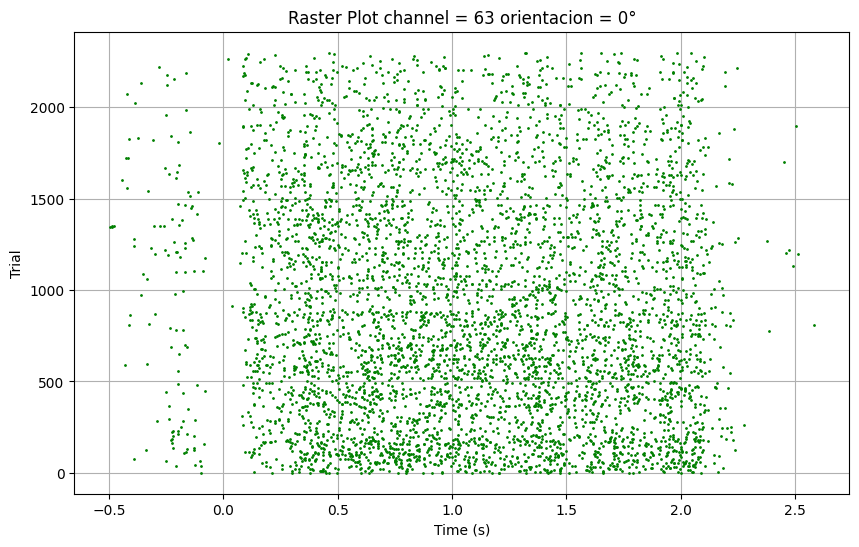

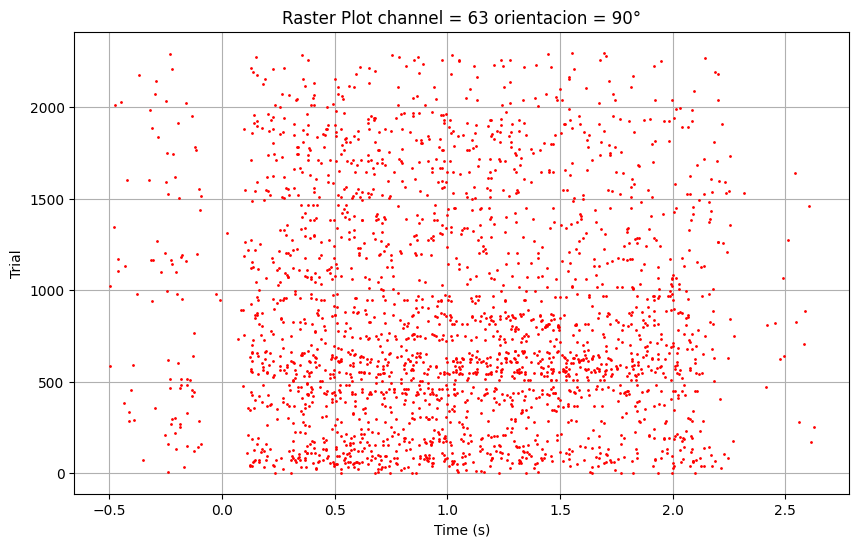

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Raster Plot channel = 63 orientacion = 0°')
plt.plot(np.array(orientation_00_63['time']), np.array(orientation_00_63['trial']) , 'g.',markersize=2)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.grid()
plt.show()


plt.figure(figsize=(10,6))
plt.title('Raster Plot channel = 63 orientacion = 90°')
plt.plot(np.array(orientation_90_63['time']), np.array(orientation_90_63['trial']) , 'r.',markersize=2)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.grid()
plt.show()

In [ ]:
df_frecuencia_80 = multielectrode.loc[(multielectrode['channel'] == 80)]

orientation_00_80 = df_frecuencia_80.loc[(df_frecuencia_80['orientation']== 0.0)]
orientation_90_80 = df_frecuencia_80.loc[(df_frecuencia_80['orientation']== 90.0)]

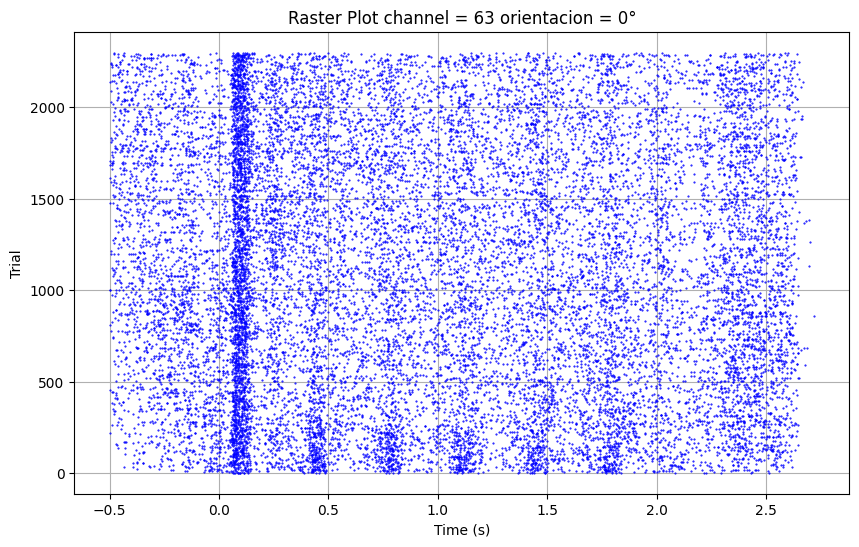

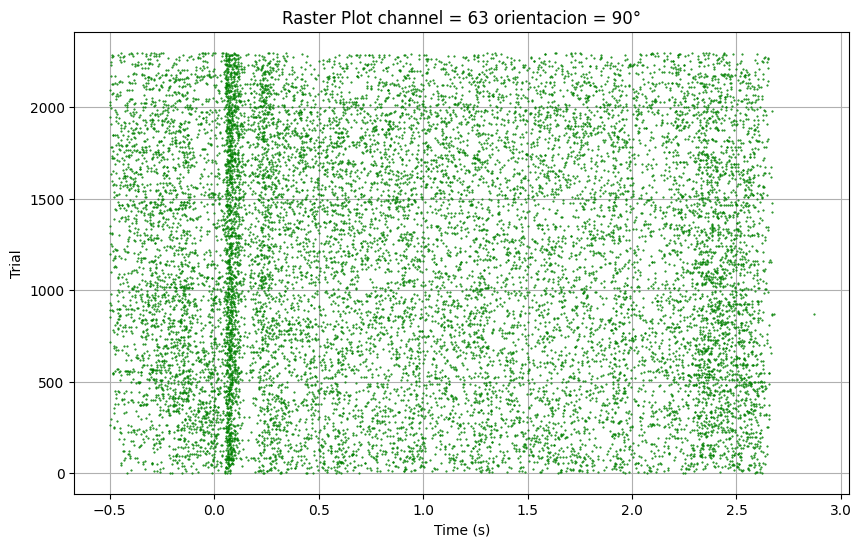

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Raster Plot channel = 63 orientacion = 0°')
plt.plot(np.array(orientation_00_80['time']), np.array(orientation_00_80['trial'])  , 'b.',markersize=1)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.grid()
plt.show()


plt.figure(figsize=(10,6))
plt.title('Raster Plot channel = 63 orientacion = 90°')
plt.plot(np.array(orientation_90_80['time']), np.array(orientation_90_80['trial']) , 'g.',markersize=1)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.grid()
plt.show()




las graficas muestran que las neuronas del canal 63 y 80 responden de forma distinta según la orientación,  el canal 63 dispara mas seguido en 0° pues hay una densidad mayor de puntos , en el canal 80 ocurre lo  contrario pues hay pocos puntos en 0 y mas 90 lo que sugiere que esa neurona responde mejor a esa orientación, por lo que cada neurona responde mejor en distintas orientaciones

## Ejercicio 2

Tome los datos de los mismos canales anteriores y calcule el PSTH para ambas condiciones. Grafique el PSTH justo debajo del raster plot correspondiente. Utilice un binning de 10 milisegundos para el histograma. Describa cómo el PSTH refleja lo que ocurre en el raster plot.

El PSTH al ser un histograma refleja mejor la distribucion del reaster plot, solo que de una forma mas organizada, por ejemplo en el raster del canal 80 podemos ver mejor como hay un patron oscuro de puntos, indicando mayor densidad y justo debajo tenemos una linea alta del histograma mstrando un mapeo ailado de todos los puntos en ese bin del raster plot, igualmente en las demas secciones del histograma superpuesto en el raster, donde hay mayor densidad de puntos sobre la acumulacion mayor de barras        

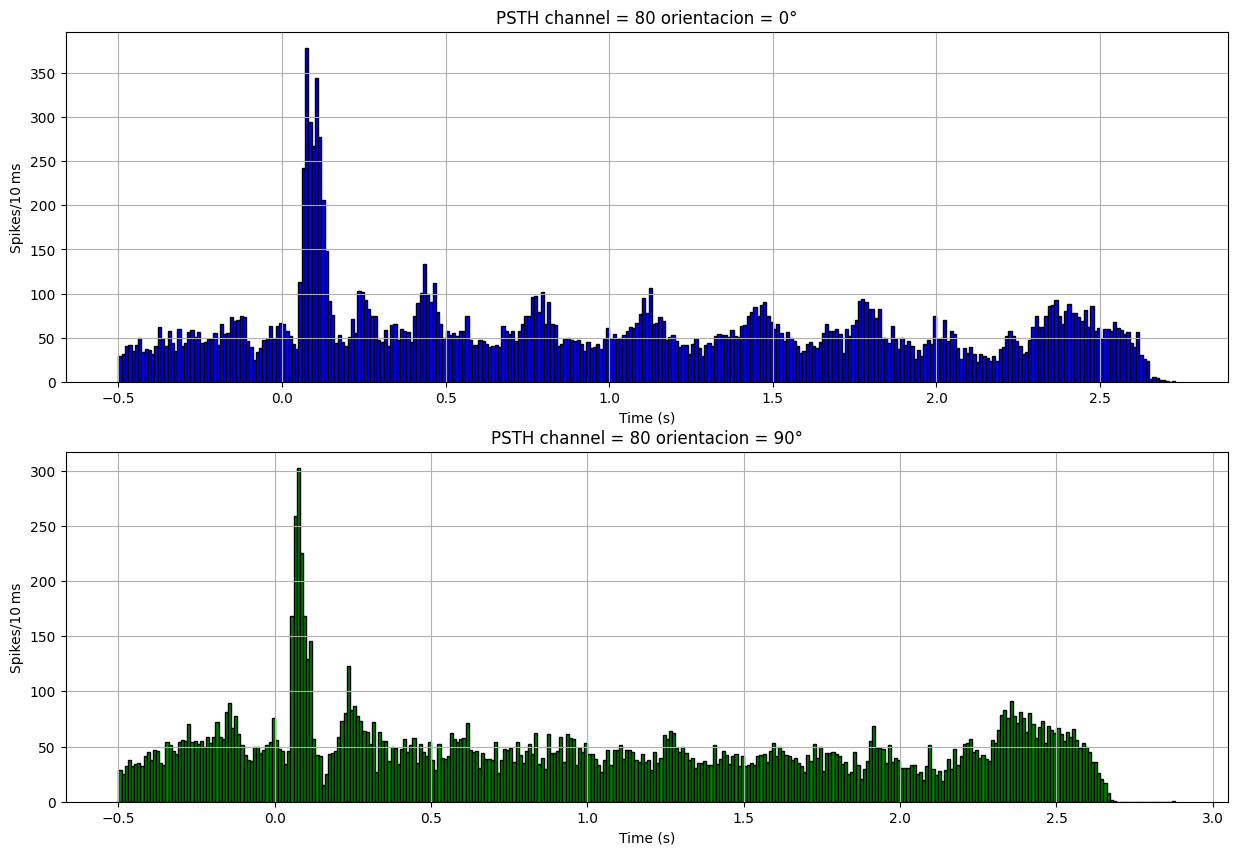

In [ ]:
# TODO
bin_width = 0.01                    #binning

#tiemos  0
t0 = orientation_00_80['time'].min()
t1 = orientation_00_80['time'].max()
bins = np.arange(t0, t1 + bin_width, bin_width)
#tiemo 90
t0_90 = orientation_90_80['time'].min()
t1_90 = orientation_90_80['time'].max()
bins2 = np.arange(t0_90, t1_90 + bin_width, bin_width)

#graficas
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.title('PSTH channel = 80 orientacion = 0°')
plt.hist(orientation_00_80['time'], bins=bins,color='blue', edgecolor='black')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.grid()



plt.subplot(2,1,2)
plt.hist(orientation_90_80['time'], bins = bins2, color = 'g',edgecolor = "black" )
plt.title('PSTH channel = 80 orientacion = 90°')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.grid()
plt.show()


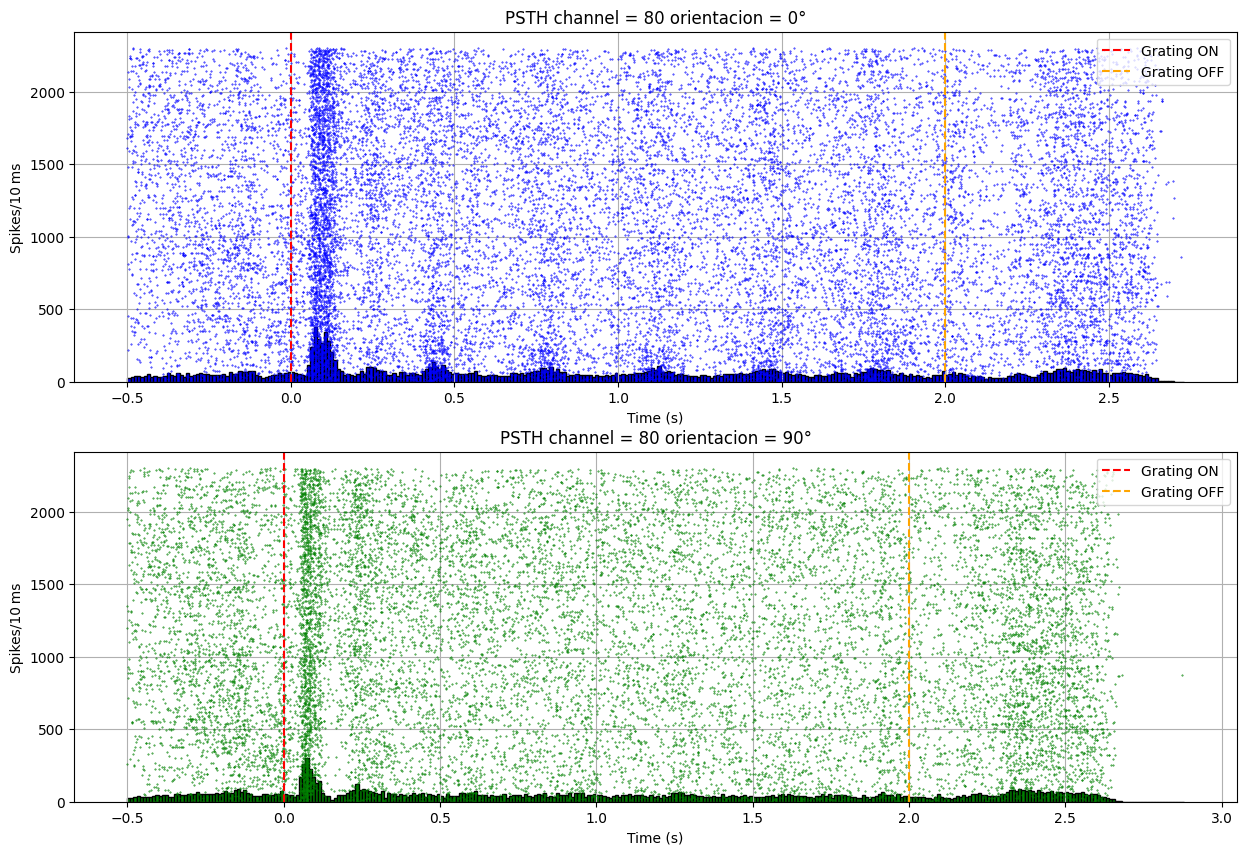

In [ ]:
bin_width = 0.01
t0 = orientation_00_80['time'].min()
t1 = orientation_00_80['time'].max()
bins = np.arange(t0, t1 + bin_width, bin_width)
t0_90 = orientation_90_80['time'].min()
t1_90 = orientation_90_80['time'].max()
bins2 = np.arange(t0_90, t1_90 + bin_width, bin_width)


plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.title('PSTH channel = 80 orientacion = 0°')
plt.plot(np.array(orientation_00_80['time']), np.array(orientation_00_80['trial'])  , 'b.',markersize=0.8)
plt.hist(orientation_00_80['time'], bins=bins,color='blue', edgecolor='black')
plt.axvline(x=0.0, color='red', linestyle='--', label='Grating ON')
plt.axvline(x=2.0, color='orange', linestyle='--', label='Grating OFF')
plt.legend()
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.grid()



plt.subplot(2,1,2)
plt.plot(np.array(orientation_90_80['time']), np.array(orientation_90_80['trial']) , 'g.',markersize=0.8)
plt.hist(orientation_90_80['time'], bins = bins2, color = 'g',edgecolor = "black" )
plt.axvline(x=0.0, color='red', linestyle='--', label='Grating ON')
plt.axvline(x=2.0, color='orange', linestyle='--', label='Grating OFF')
plt.title('PSTH channel = 80 orientacion = 90°')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()


plt.show()

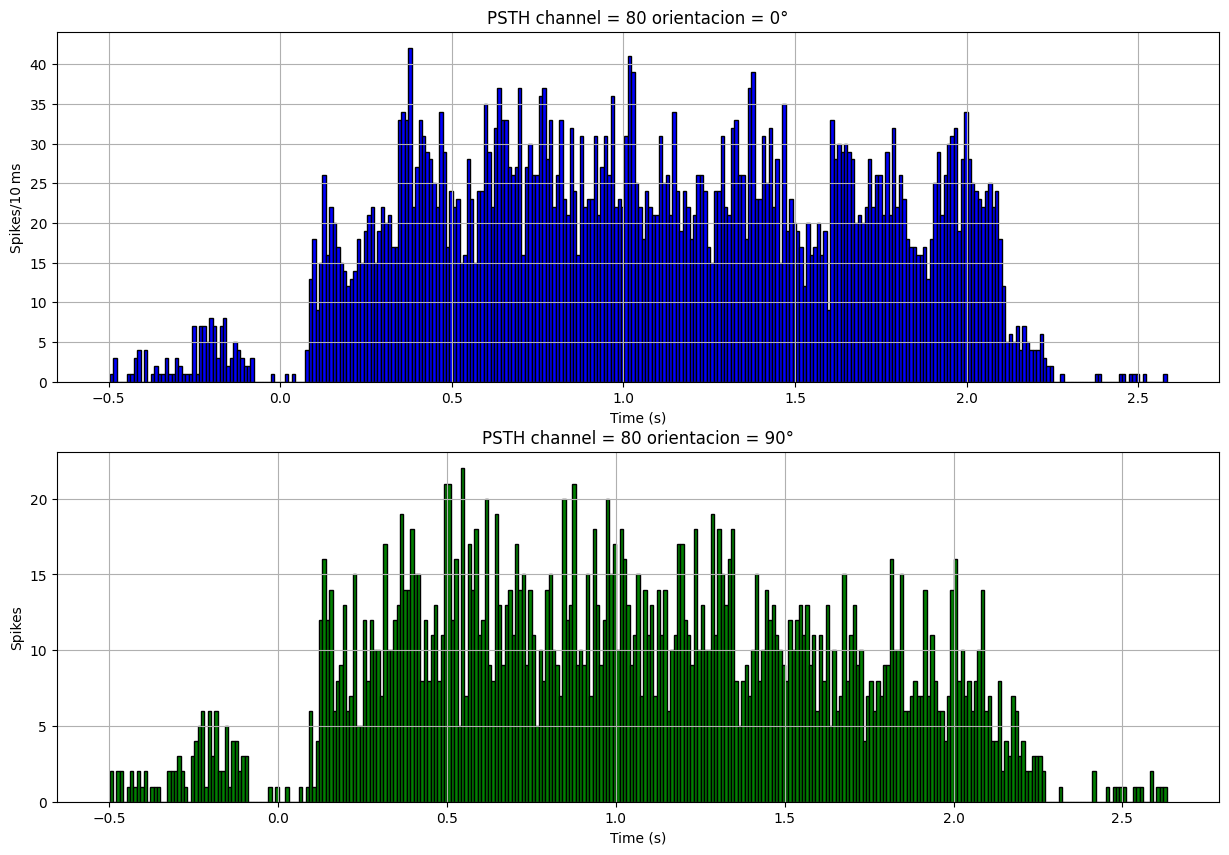

In [ ]:
bin_width = 0.01
#TIEMOS ORIENTACION 0
t0 = orientation_00_63['time'].min()
t1 = orientation_00_63['time'].max()
bins = np.arange(t0, t1 + bin_width, bin_width)
#TIEMOS  ORIENTACION 90
t0_90 = orientation_90_63['time'].min()
t1_90 = orientation_90_63['time'].max()
bins2 = np.arange(t0_90, t1_90 + bin_width, bin_width)

#GRAFICAS
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.title('PSTH channel = 80 orientacion = 0°')
plt.hist(orientation_00_63['time'], bins=bins,color='blue', edgecolor='black')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.grid()
plt.subplot(2,1,2)
plt.hist(orientation_90_63['time'], bins = bins2, color = 'g',edgecolor = "black" )
plt.title('PSTH channel = 80 orientacion = 90°')
plt.ylabel('Spikes')
plt.xlabel('Time (s)')
plt.grid()
plt.show()

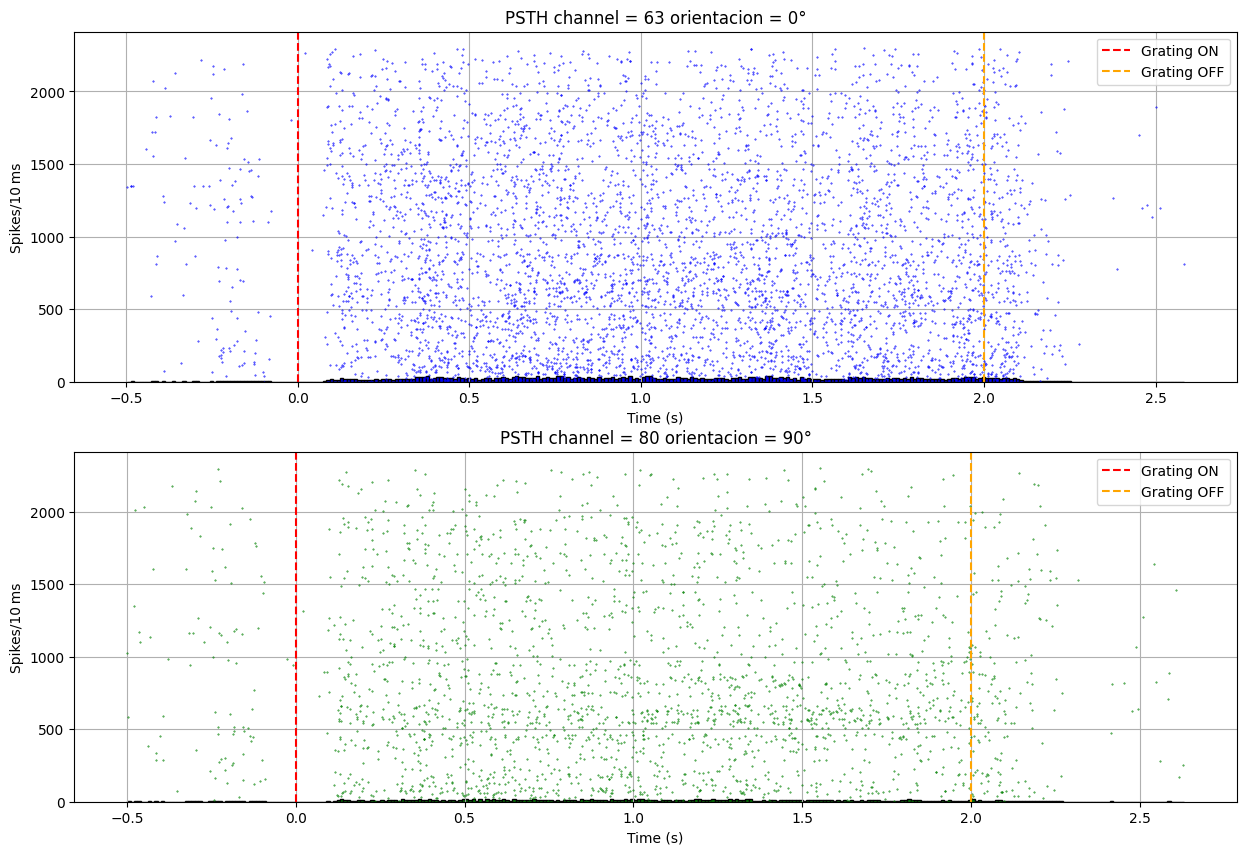

In [ ]:
bin_width = 0.01
t0 = orientation_00_63['time'].min()
t1 = orientation_00_63['time'].max()
bins = np.arange(t0, t1 + bin_width, bin_width)
t0_90 = orientation_90_63['time'].min()
t1_90 = orientation_90_63['time'].max()
bins2 = np.arange(t0_90, t1_90 + bin_width, bin_width)


plt.figure(figsize=(15,10))
plt.subplot(2,1,1)

plt.title('PSTH channel = 63 orientacion = 0°')
plt.plot(np.array(orientation_00_63['time']), np.array(orientation_00_63['trial'])  , 'b.',markersize=0.8)

plt.hist(orientation_00_63['time'], bins=bins,color='blue', edgecolor='black')

plt.axvline(x=0, color='red', linestyle='--', label='Grating ON')
plt.axvline(x=2, color='orange', linestyle='--', label='Grating OFF')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()



plt.subplot(2,1,2)
plt.plot(np.array(orientation_90_63['time']), np.array(orientation_90_63['trial']) , 'g.',markersize=0.8)
plt.hist(orientation_90_63['time'], bins = bins2, color = 'g',edgecolor = "black" )
plt.axvline(x=0, color='red', linestyle='--', label='Grating ON')
plt.axvline(x=2, color='orange', linestyle='--', label='Grating OFF')
plt.title('PSTH channel = 80 orientacion = 90°')
plt.ylabel('Spikes/10 ms')
plt.xlabel('Time (s)')
plt.grid()
plt.legend()


plt.show()

## Ejercicio 3

Muestre en un arreglo de 20 subplots los PSTH correspondientes a la orientación de 0 y 90 para todas las neuronas.

In [ ]:
canales =sorted(chanel.unique())

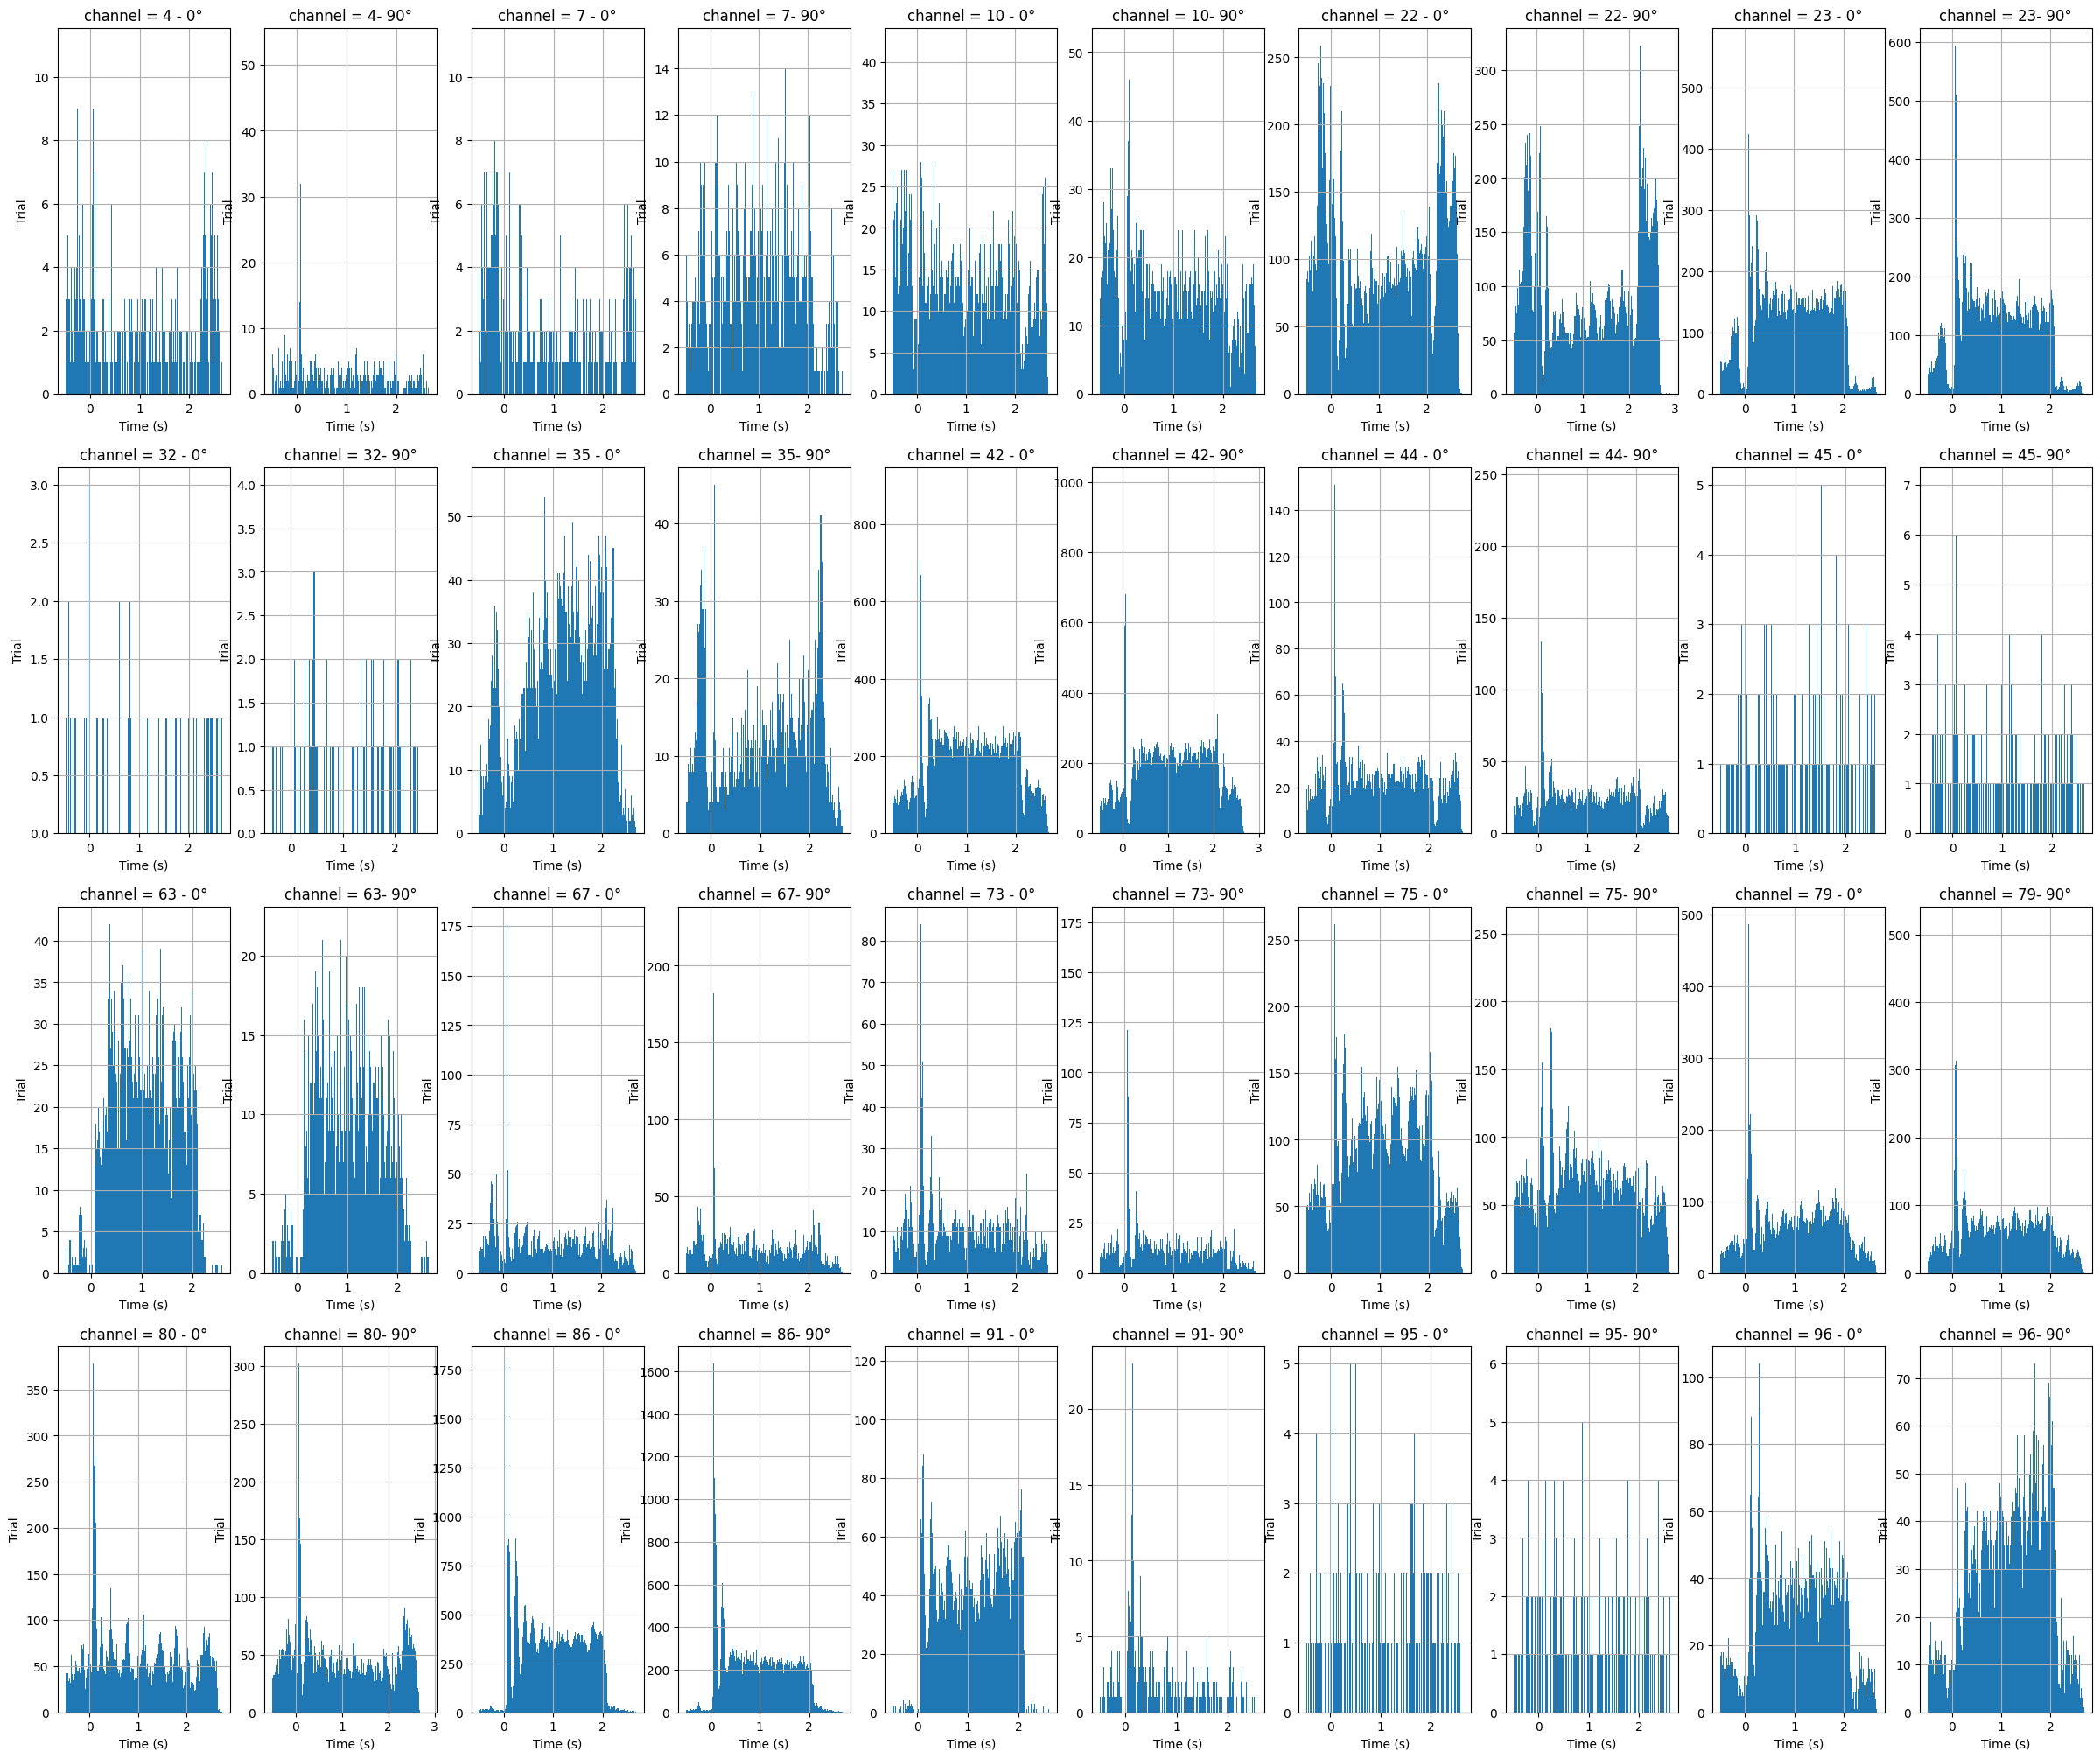

In [ ]:
plt.figure(figsize=(30,25))
rows, cols = 4, 10


for idx,canal in enumerate(canales):
    canal_ = multielectrode[multielectrode['channel'] == canal]
    orientation_00_ = canal_[canal_['orientation'] == 0.0]
    orientation_90_ = canal_.loc[(canal_['orientation']== 90.0)]

    bin_width = 0.01

    t0r = orientation_90_['time'].min()
    t1r = orientation_90_['time'].max()
    binr = np.arange(t0r, t1r + bin_width, bin_width)
    t0 = orientation_00_['time'].min()
    t1 = orientation_00_['time'].max()
    bins = np.arange(t0, t1 + bin_width, bin_width)

    pos = idx * 2 + 1
    plt.subplot(rows, cols, pos)
    plt.title(f'channel = {round(canal)} - 0°')
    plt.hist(orientation_00_['time'], bins=bins)

    plt.xlabel('Time (s)')
    plt.ylabel('Trial')
    plt.grid()


    plt.subplot(rows, cols, pos + 1)

    plt.title(f'channel = {round(canal)}- 90°')
    plt.hist(orientation_90_['time'], bins=binr)
    plt.xlabel('Time (s)')
    plt.ylabel('Trial')
    plt.grid()
plt.show()

## Ejercicio 4:

Recuerde que el experimento original tenía 96 canales, sin embargo en los datos anteriores solo vimos 20 de ellos. Esto es porque los datos originales con los datos de los spikes de todos los canales para los 3000 ensayos sería excesivamente grande para trabajar. Sin embargo ya hemos visto que el PSTH nos da una información reducida de los que ocurre en cada canal para los 3000 experimentos. En el archivo *array_psth.csv* que encontrará a continuación se encuentran los PSTH ya calculados para las 96 neuronas para los primeros 2150 ms de experimento. Para esto se ha usado un binning de 8ms.

Cargue el archivo y muestre la matriz de correlación entre los PSTH de las diferentes neuronas. La matriz resultante es la matriz de conectividad funcional. Restrinja su análisis a los datos correspondientes al intervalo de estimulación.

Encuentra diferencias entre las conectividades funcionales entre las distintas neuronas para las orientaciones de 0 y 90?

In [ ]:
# TODO
array_psth = pd.read_csv('/content/drive/MyDrive/datos/array_psth.csv')
array_psth.head()

,orientation,channel,0,1,2,3,4,5,6,7,...,259,260,261,262,263,264,265,266,267,268
0,0.0,1.0,14,32,22,14,29,28,56,74,...,19,12,12,13,16,16,15,19,21,11
1,90.0,1.0,15,32,19,18,26,40,42,54,...,15,17,22,14,27,21,19,21,18,17
2,0.0,2.0,2,3,0,6,2,2,0,3,...,1,1,1,0,1,0,0,2,0,0
3,90.0,2.0,3,1,3,2,2,4,5,2,...,3,2,1,0,2,2,3,1,2,0
4,0.0,3.0,8,1,3,3,6,4,4,8,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
orientacion0 = array_psth.loc[array_psth["orientation"] == 0]
orientacion90 = array_psth.loc[array_psth["orientation"] == 90]

In [ ]:
columnas = list(orientacion0.columns)

fijas =["orientation","channel"]

tiemo_estumils = list()

for tiemo in columnas:
    if tiemo in fijas:
        continue

    tiemo_ent = int(tiemo)

    if tiemo_ent>0 and tiemo_ent<=249:       #los datos solo tienen hasta 268*8 = 2144 son los bins del PSTH ara que sea  2 s osea 2000ms  2000/8 ~ 250
        tiemo_estumils.append(str(tiemo))


columns_90 = list(orientacion90.columns)
tiemo_estumils_90 = list()

for tiemo in columns_90:
    if tiemo in fijas:
        continue

    tiemo_ent = int(tiemo)

    if tiemo_ent>0 and tiemo_ent<=249:
        tiemo_estumils_90.append(str(tiemo))




In [ ]:
datos0 = orientacion90[fijas + tiemo_estumils_90]
datos90 = orientacion0[fijas + tiemo_estumils]

In [ ]:
x0 = datos0.drop(columns= fijas)
x00 = x0 = datos90.drop(columns= fijas)

In [ ]:
matriz_corr_0 = x0.T.corr()
matriz_corr_90 = x00.T.corr()

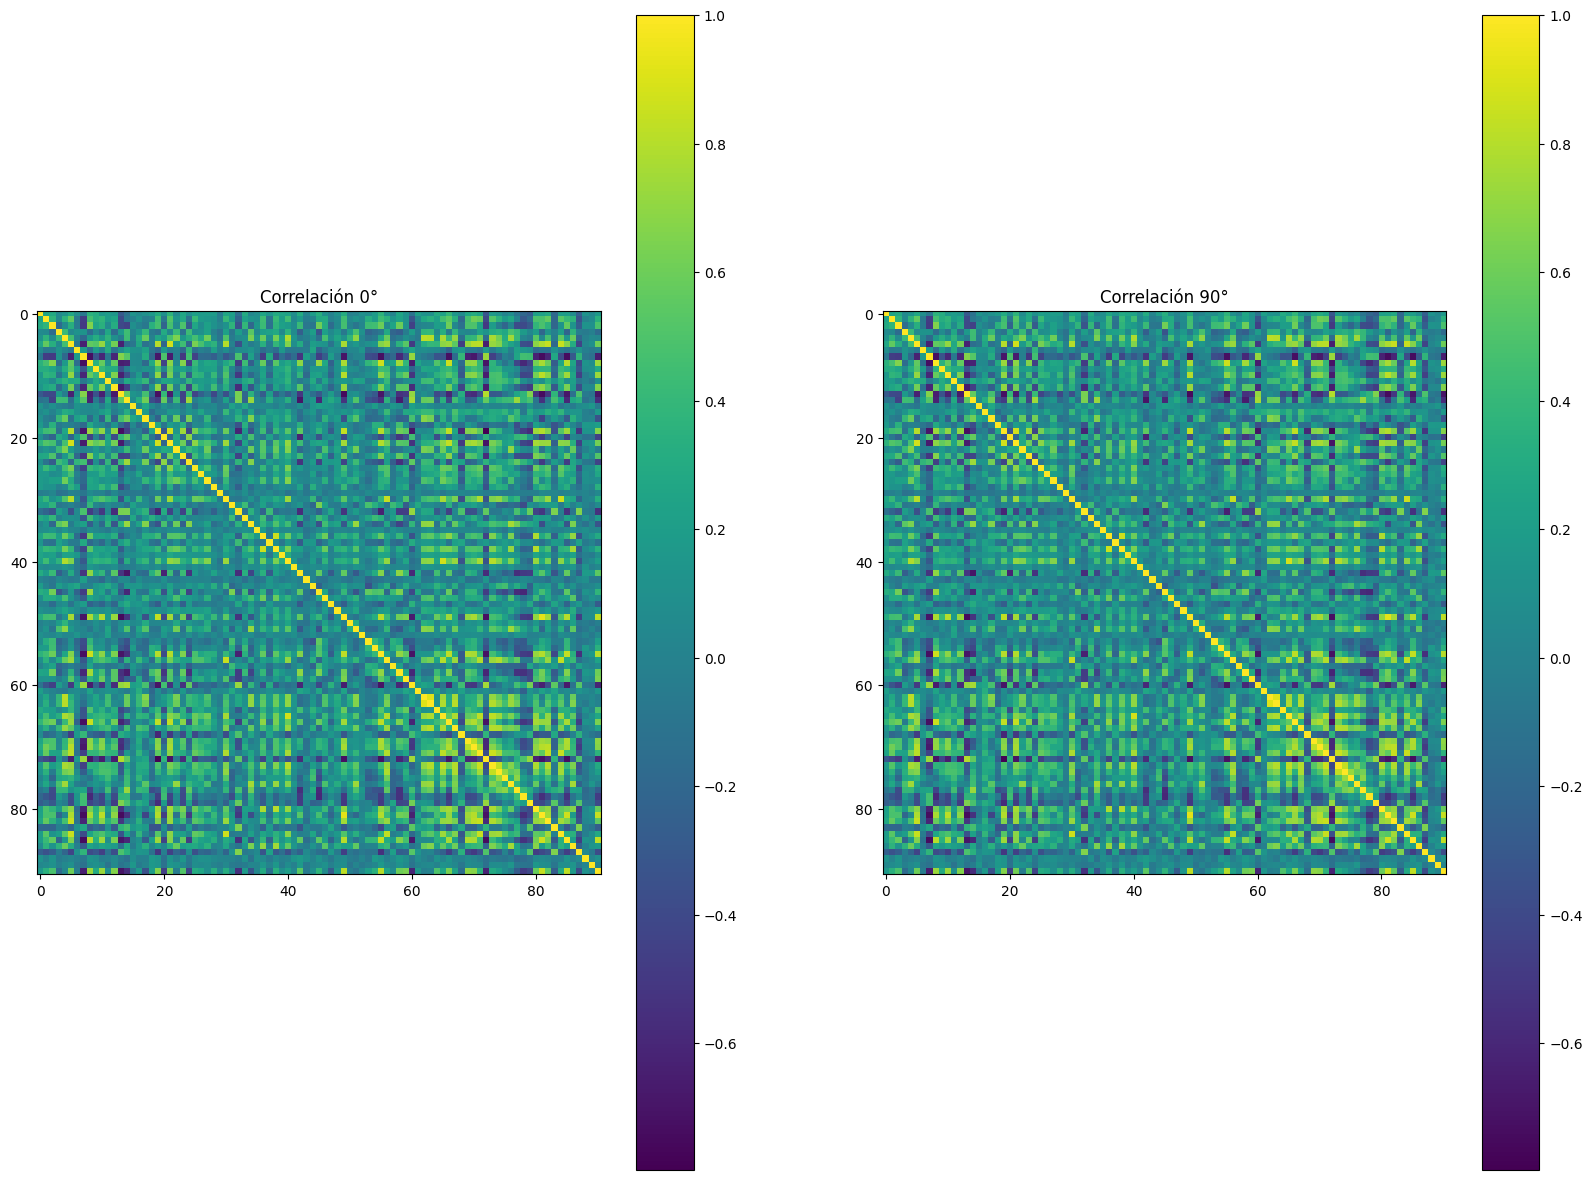

In [ ]:
plt.figure(figsize=(20,15))

plt.subplot(1, 2, 1)
plt.imshow(matriz_corr_0, cmap='viridis')
plt.title('Correlación 0°')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(matriz_corr_90, cmap='viridis')
plt.title('Correlación 90°')
plt.colorbar()
plt.show()

A simple vista Las dos matrices revelan que la red neuronal no mantiene la su organización cuando cambia la orientación de la regilla,a 0° se ven mas  cuadros mas amarillos verdosos que indican correlaciones altas y algunos grupitos claros fuera de la diagonal, parece que guardan mayor correlacion o que se conectan mas entres si, mientras en 90° la matriz se vuelve más verdosa con toques de azul  y aparecen varios puntos azul oscuro, lo que parece mostrar que algunas neuronas ya no se sincronizan o no guardan correlacion.  

la red parece mostrar correlacion y en sintesis conexiones sinapticas mejor estructuradas a 0° que a 90°.  


